# Notebook 01 — Packet Counter Reconstruction
**Thesis:** §4.2 (Definition 1), §5.1, §5.2, §5.2.1 | **Output:** `data/reconstructed.csv`

---

## *** Is there any way in which the particle-wave duality of the radio waves affects this research?
## Purpose
Reconstructs the history of lost packets — invisible in the received dataset by definition.

Two counters are embedded in every LoRaWAN transmission:

| Counter | Layer | Increments when | Gap meaning |
|---------|-------|----------------|-------------|
| `f_count` | MAC (radio) | Radio fires | **Radio losses** |
| `p_count` | Application | App prepares packet | Radio losses + internal drops |

Comparing both counters decomposes every loss interval into three components:

| Column | Meaning | Used for |
|--------|---------|---------|
| `mac_to_radio_loss` | Packet entered air, never received | **Primary — event analysis** |
| `app_to_mac_drop` | Packet never reached the radio | Future work (§9.4) |
| `total_loss` | Full system loss (p_count equivalent) | Cross-validation |

Two categories of non-environmental losses are identified and flagged:
- **Infrastructure outages** — gateway/server downtime, all devices simultaneously
- **SF rotation artifacts** — deterministic losses at SF7→SF10 transitions

Event-conditioned analysis in notebooks 03–04 uses only the filtered radio-layer losses.

## 0 · Imports & Paths

In [32]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)
RAW_CSV = DATA_DIR / '0_cleaned_dataset_Obiri_2025_2.csv'
OUT_CSV = DATA_DIR / '1_reconstructed.csv'

In [33]:
# Figures Definition
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})
C = {'blue': '#0077BB', 'orange': '#EE7733', 'green': '#009988',
     'red': '#CC3311', 'purple': '#AA3377', 'navy': '#004488', 'grey': '#BBBBBB',
     'brown': '#882255'}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]
FIG_DIR = Path('../figures');
FIG_DIR.mkdir(exist_ok=True)


def save_fig(fig, name):
    fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/{name}.pdf + .png')
    plt.show()


print(f'Figure style ready. Saving to: {FIG_DIR.resolve()}')


Figure style ready. Saving to: D:\Thesis\lorawan_master_thesis\figures


## 1 · Load & Sort  *(§5.1.1)*
Timestamps parsed as UTC — avoids DST ambiguity (two transitions during the 34-week campaign).  
Sorted per device by time — InfluxDB export order is not guaranteed.

In [2]:
df = pd.read_csv(RAW_CSV)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')
print(f'Campaign: {df["time"].min().date()} to {df["time"].max().date()}')

NameError: name 'pd' is not defined

## 2 · Packet Counter Reconstruction  *(Definition 1, §4.2)*

$$\ell_i = \max(\Delta f_i - 1,\ 0)$$

For each consecutive pair of received packets from the same device:
- `delta_f` = f_count gap → how many radio transmissions happened since last reception
- `delta_p` = p_count gap → how many application-layer attempts happened
- `mac_to_radio_loss` = `max(delta_f − 1, 0)` → packets that entered the air but were lost
- `app_to_mac_drop` = `delta_p − delta_f` → packets dropped before the radio fired

**Reset detection:** negative delta_f = device rebooted, counter reset to zero.  
These intervals are flagged (`is_reset`) and excluded from PDR — loss count is unknowable.

In [1]:
def reconstruct(grp):
    grp = grp.copy().reset_index(drop=True)

    delta_f = grp['f_count'].diff()  # MAC-layer gap → radio losses
    delta_p = grp['p_count'].diff()  # app-layer gap → total system losses
    is_reset = delta_f < 0  # negative gap → device rebooted

    # Definition 1 §4.2: mac-to-radio loss = max(Δf − 1, 0)
    mac_loss = (delta_f - 1).clip(lower=0)
    mac_loss[is_reset] = 0  # loss unknown at reboot — conservatively 0
    mac_loss.iloc[0] = 0  # no prior interval for first received packet

    # app-to-MAC drops: packets the application prepared but the radio never fired
    app_drop = (delta_p - delta_f).clip(lower=0)
    app_drop[is_reset] = 0
    app_drop.iloc[0] = 0

    grp['mac_to_radio_loss'] = mac_loss.astype(int)  # primary metric
    grp['app_to_mac_drop'] = app_drop.astype(int)  # future work
    grp['total_loss'] = (mac_loss + app_drop).astype(int)  # p_count equivalent
    grp['is_reset'] = is_reset.fillna(False)  # reboot flag
    grp['total_tx'] = 1 + grp['mac_to_radio_loss']  # TX attempts per interval
    return grp


# pandas 3.0 drops grouping column inside apply — save and restore
device_ids = df['device_id'].copy()
df = df.groupby('device_id', group_keys=False).apply(reconstruct)
df['device_id'] = device_ids.values
df = df.reset_index(drop=True)

print('Reconstruction done.')
print(df['device_id'].value_counts().sort_index())

NameError: name 'df' is not defined

## 3 · Counter Divergence Cross-Check  *(Table 5.2, §5.2.1)*

`p_count` grows faster than `f_count` because it increments before the radio fires.  
The cumulative difference between their ranges ≈ total `app_to_mac_drop`.  
This is an independent validation of the reconstruction — no counter gaps used here, just range comparison.

In [36]:
div = df.groupby('device_id').agg(
    p_min=('p_count', 'min'), p_max=('p_count', 'max'),
    f_min=('f_count', 'min'), f_max=('f_count', 'max'),
).reset_index()
div['p_range'] = div['p_max'] - div['p_min']
div['f_range'] = div['f_max'] - div['f_min']
div['divergence'] = div['p_range'] - div['f_range']
div['pct'] = (div['divergence'] / div['p_range'] * 100).round(1)

print(f"{'Device':<8} {'p_range':>10} {'f_range':>10} {'divergence':>12} {'pct':>6}")
print('-' * 52)
for _, row in div.iterrows():
    print(f"{row['device_id']:<8} {int(row['p_range']):>10,} "
          f"{int(row['f_range']):>10,} {int(row['divergence']):>12,} {row['pct']:>5.1f}%")

Device      p_range    f_range   divergence    pct
----------------------------------------------------
ED0         203,893    183,833       20,060   9.8%
ED1         363,580    322,405       41,175  11.3%
ED2         363,603    325,311       38,292  10.5%
ED3         251,676    223,787       27,889  11.1%
ED4         363,569    322,427       41,142  11.3%
ED5         363,710    331,373       32,337   8.9%


  Saved: figures/01_a_counter_divergence.pdf + .png


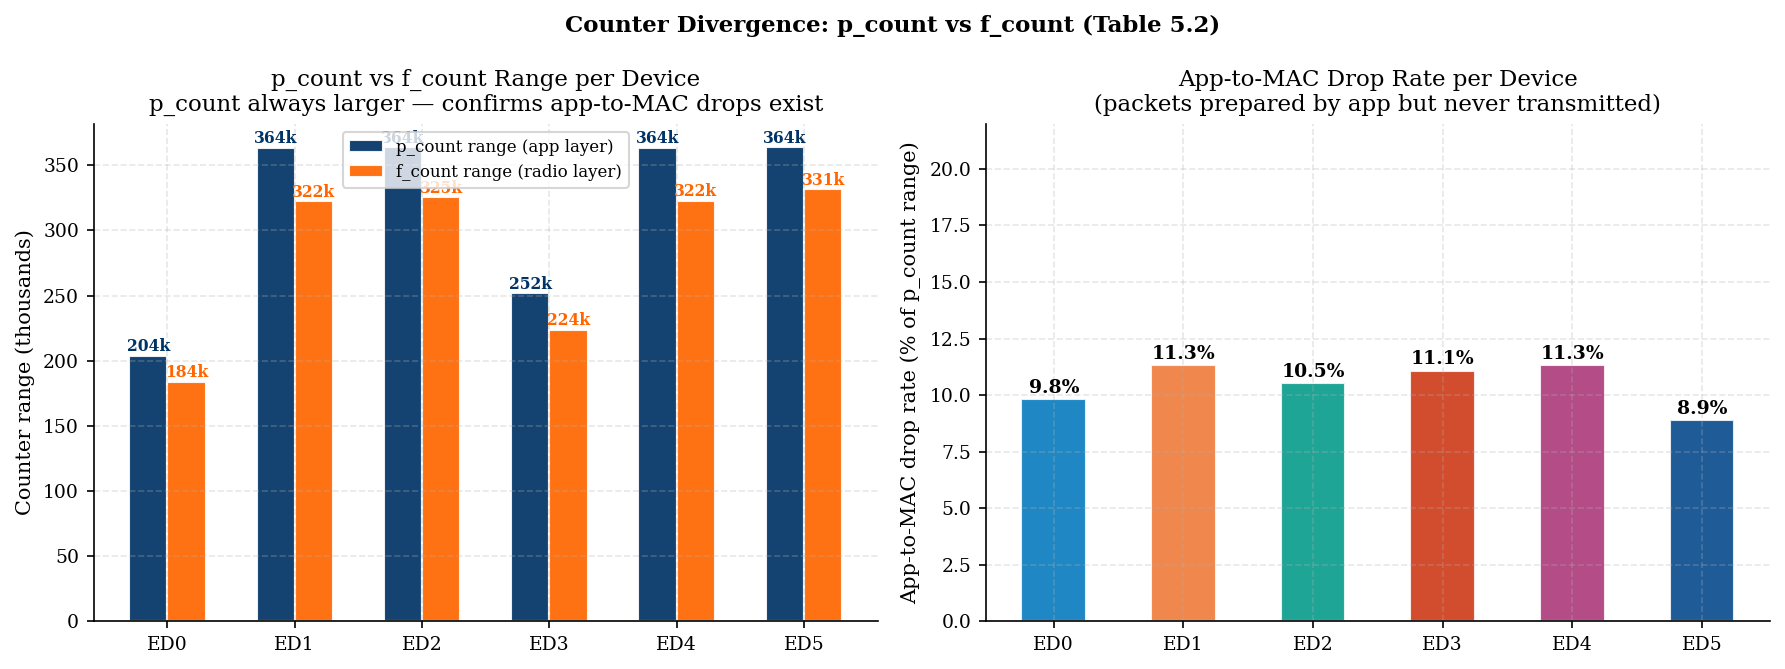

In [37]:
# Fig 01_a — Counter Divergence: p_count vs f_count per Device
div_data = df.groupby('device_id').agg(
    p_range=('p_count', lambda x: x.max() - x.min()),
    f_range=('f_count', lambda x: x.max() - x.min()),
).reset_index()
div_data['divergence'] = div_data['p_range'] - div_data['f_range']
div_data['div_pct'] = div_data['divergence'] / div_data['p_range'] * 100
DEVICES_D = div_data['device_id'].tolist()

x = np.arange(len(DEVICES_D));
w = 0.3
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# high contrast: dark navy vs bright orange — easy to distinguish
b1 = axes[0].bar(x - w / 2, div_data['p_range'] / 1000, w,
                 color='#003366', alpha=0.92, label='p_count range (app layer)', edgecolor='white')
b2 = axes[0].bar(x + w / 2, div_data['f_range'] / 1000, w,
                 color='#FF6600', alpha=0.92, label='f_count range (radio layer)', edgecolor='white')
for bar, v in zip(b1, div_data['p_range'] / 1000):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.5, f'{v:.0f}k',
                 ha='center', va='bottom', fontsize=7.5, color='#003366', fontweight='bold')
for bar, v in zip(b2, div_data['f_range'] / 1000):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.5, f'{v:.0f}k',
                 ha='center', va='bottom', fontsize=7.5, color='#FF6600', fontweight='bold')
axes[0].set_xticks(x);
axes[0].set_xticklabels(DEVICES_D)
axes[0].set_ylabel('Counter range (thousands)')
axes[0].set_title('p_count vs f_count Range per Device\np_count always larger — confirms app-to-MAC drops exist')
axes[0].legend(fontsize=8)

# right: divergence % per device
bars = axes[1].bar(DEVICES_D, div_data['div_pct'],
                   color=DEVICE_COLORS[:len(DEVICES_D)], width=0.5, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, div_data['div_pct']):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('App-to-MAC drop rate (% of p_count range)')
axes[1].set_title('App-to-MAC Drop Rate per Device\n(packets prepared by app but never transmitted)')
axes[1].set_ylim(0, 22)

fig.suptitle('Counter Divergence: p_count vs f_count (Table 5.2)', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_a_counter_divergence')


## 4 · Loss Distribution Analysis  *(§5.2)*

Examines the distribution of `mac_to_radio_loss` values to find natural break points.  
Three zones emerge from the data — justified empirically, not assumed:

| Zone | Loss range | Interpretation |
|------|-----------|---------------|
| Radio | 1–9 | Dense cluster — genuine radio-layer failures |
| Ambiguous | 10–59 | Sparse desert — cause unclassifiable |
| Outage | 60+ | All devices simultaneously — infrastructure failure |

The spike at `loss=8` (dominated by SF10) will be explained in §6.

In [38]:
losses = df[df['mac_to_radio_loss'] > 0]['mac_to_radio_loss']

# individual value counts — radio zone
print(f"{'Loss Value':<12} {'Intervals':>12} {'% of loss intervals':>20}")
print('-' * 46)
for v in range(1, 10):
    cnt = int((losses == v).sum())
    print(f"{v:<12} {cnt:>12,} {cnt / len(losses) * 100:>19.1f}%")
for label, mask in [('10-59', losses.between(10, 59)), ('60+', losses >= 60)]:
    cnt = int(mask.sum())
    print(f"{label:<12} {cnt:>12,} {cnt / len(losses) * 100:>19.1f}%")
print('-' * 46)
print(f"{'Total':<12} {len(losses):>12,}")

# per-device breakdown
print(f"\n{'Device':<8} {'Radio(1-9)':>12} {'Ambiguous':>12} {'Outage(60+)':>12}")
print('-' * 48)
for dev, g in df.groupby('device_id'):
    dl = g[g['mac_to_radio_loss'] > 0]['mac_to_radio_loss']
    print(f"{dev:<8} {int((dl <= 9).sum()):>12,} "
          f"{int(dl.between(10, 59).sum()):>12,} {int((dl >= 60).sum()):>12,}")

Loss Value      Intervals  % of loss intervals
----------------------------------------------
1                  35,154                80.4%
2                   5,570                12.7%
3                   1,120                 2.6%
4                     545                 1.2%
5                     455                 1.0%
6                     144                 0.3%
7                      75                 0.2%
8                      65                 0.1%
9                      46                 0.1%
10-59                 368                 0.8%
60+                   188                 0.4%
----------------------------------------------
Total              43,730

Device     Radio(1-9)    Ambiguous  Outage(60+)
------------------------------------------------
ED0             7,520           51           31
ED1             9,304           45           31
ED2             6,668           47           32
ED3             8,849           93           31
ED4             7,955     

  Saved: figures/01_b_loss_distribution_zones.pdf + .png


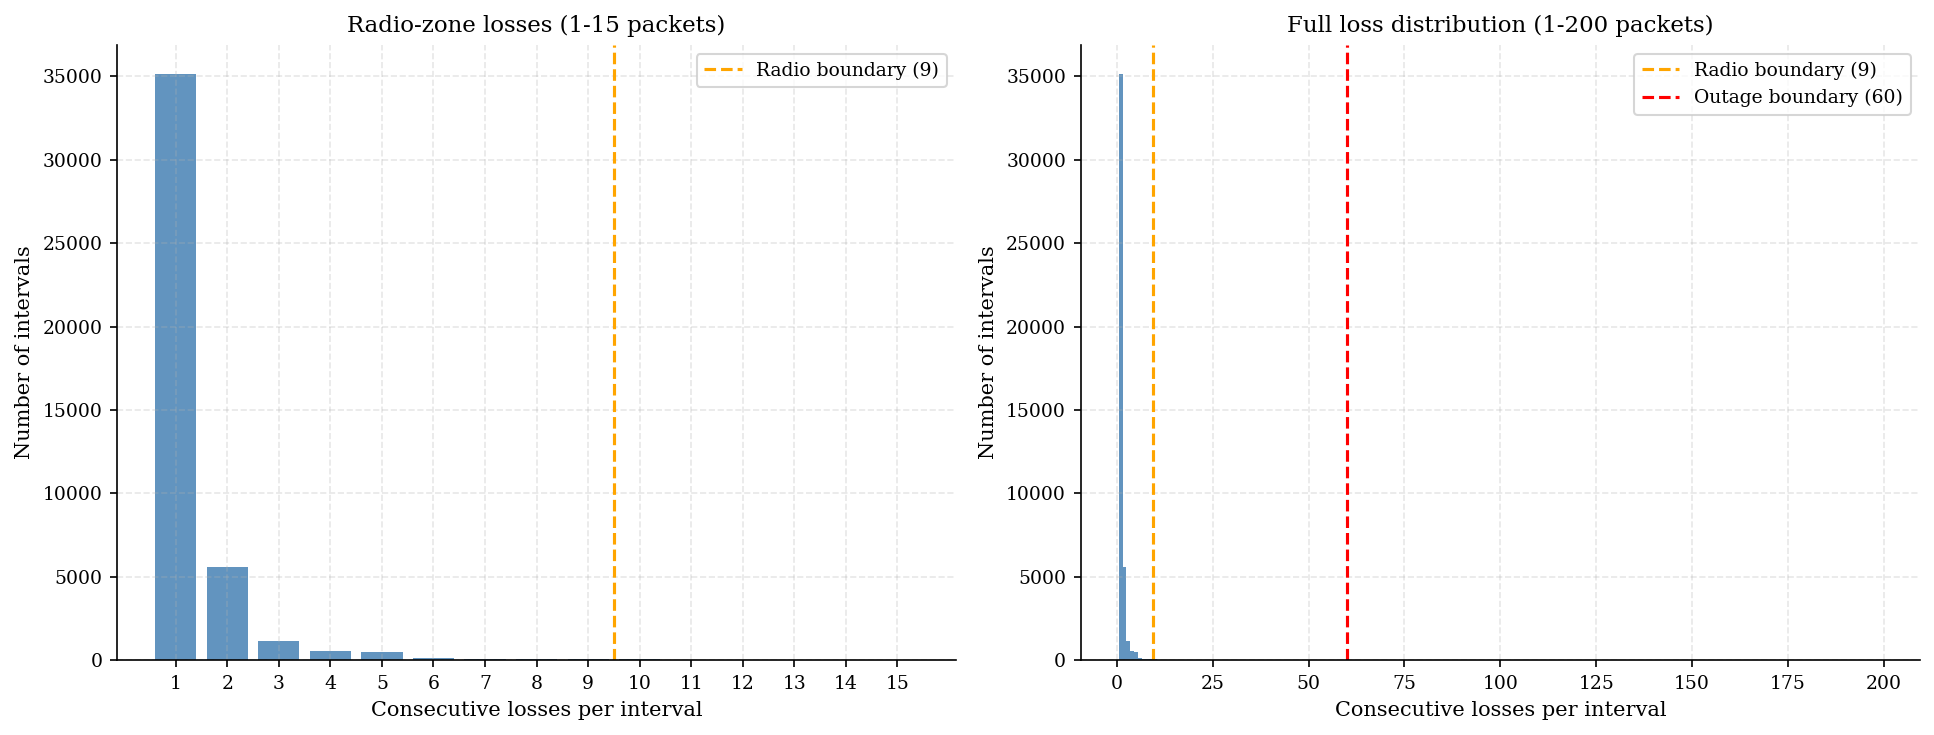

In [39]:
# two-panel figure — radio zone + full distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lz = losses[losses <= 15].value_counts().sort_index()
axes[0].bar(lz.index, lz.values, color='steelblue', width=0.8, alpha=0.85)
axes[0].axvline(x=9.5, color='orange', lw=1.5, ls='--', label='Radio boundary (9)')
axes[0].set_xlabel('Consecutive losses per interval')
axes[0].set_ylabel('Number of intervals')
axes[0].set_title('Radio-zone losses (1-15 packets)')
axes[0].set_xticks(range(1, 16))
axes[0].legend()

lc = losses[losses <= 200].value_counts().sort_index()
axes[1].bar(lc.index, lc.values, color='steelblue', width=1, alpha=0.85)
axes[1].axvline(x=9.5, color='orange', lw=1.5, ls='--', label='Radio boundary (9)')
axes[1].axvline(x=60, color='red', lw=1.5, ls='--', label='Outage boundary (60)')
axes[1].set_xlabel('Consecutive losses per interval')
axes[1].set_ylabel('Number of intervals')
axes[1].set_title('Full loss distribution (1-200 packets)')
axes[1].legend()

plt.tight_layout()
save_fig(fig, '01_b_loss_distribution_zones')

## 5 · Infrastructure Outage Detection  *(§5.2)*

**Threshold: `mac_to_radio_loss ≥ 60`** (1 hour of continuous loss at 60s/transmission).

**Justification — two lines of evidence:**
1. The loss distribution shows a natural desert between 10 and 59 — no clustering at any value
2. Every identified outage event affects **all six devices simultaneously on the same date** — impossible for radio-layer failures which are device-specific

Flagged as `is_outage = True`. Excluded from all event-conditioned analysis.

In [40]:
OUTAGE_THRESHOLD = 60  # 1 hour at 60s per transmission

large = df[df['mac_to_radio_loss'] >= OUTAGE_THRESHOLD][['device_id', 'time', 'mac_to_radio_loss']].copy()
large['date'] = pd.to_datetime(large['time']).dt.date
large['hrs'] = (large['mac_to_radio_loss'] * 60 / 3600).round(1)
dates = {d: i + 1 for i, d in enumerate(sorted(large['date'].unique()))}
large['event'] = large['date'].map(dates)

# summary — one row per event, shows cross-device simultaneity
summary = large.groupby('event').agg(
    date=('date', 'first'),
    devices=('device_id', 'nunique'),
    max_hrs=('hrs', 'max')
).reset_index()

print(f'Outage intervals: {len(large)}  |  Unique events: {large["event"].nunique()}')
print(f"\n{'Event':^6} {'Date':^12} {'Devices Affected':^18} {'Max Duration (hrs)':^20}")
print('-' * 60)
for _, row in summary.iterrows():
    print(f"{int(row['event']):^6} {str(row['date']):^12} {int(row['devices']):^18} {row['max_hrs']:^20.1f}")

# flag in main dataframe
df['is_outage'] = df['mac_to_radio_loss'] >= OUTAGE_THRESHOLD
print(f'\nis_outage: {df["is_outage"].sum()} intervals flagged')

Outage intervals: 188  |  Unique events: 28

Event      Date      Devices Affected   Max Duration (hrs) 
------------------------------------------------------------
  1     2024-10-10          6                  4.5         
  2     2024-10-11          6                  1.1         
  3     2024-10-13          6                  15.0        
  4     2024-10-17          6                  1.5         
  5     2024-10-23          6                  1.4         
  6     2024-10-30          6                  7.3         
  7     2024-12-16          1                  2.1         
  8     2025-01-27          6                  3.6         
  9     2025-02-25          6                 184.2        
  10    2025-02-26          6                  5.2         
  11    2025-02-28          6                  40.4        
  12    2025-03-29          6                  9.3         
  13    2025-04-07          6                  3.4         
  14    2025-05-20          6                  16.8   

## 6 · SF Rotation Artifact Detection  *(Novel finding — §5.2, §9.4)*

ADR was disabled and SFs were manually rotated across the campaign (Obiri & Van Laerhoven, 2025).  
The rotation cycle observed: **SF9 → SF8(×5) → SF7(×5) → SF10(×5) → repeat**.

**Finding:** A systematic loss artifact occurs at the **SF7→SF10 transition**:
- `mac_to_radio_loss = 8`, `app_to_mac_drop = 2` at SF10 → **52,672 intervals** (81.6% of SF10 losses)
- `app_to_mac_drop ≥ 8` at SF9 following abbreviated SF10 → **3,413 intervals** (99.4% preceded by SF7)

**Predecessor verification confirms the mechanism:**  
99.97% of SF10 artifacts and 99.4% of SF9 artifacts are immediately preceded by SF7 — confirming the SF7→SF10 transition as the root cause.

The larger the ToA jump, the more severe the artifact:

| Transition | ToA jump | Artifact severity |
|-----------|---------|-----------------|
| SF7→SF8/SF9 | Small | None detected |
| SF7→SF10 | 71.9→452.6 ms (6×) | Dominant (81.6% of SF10 losses) |

Flagged as `is_sf_artifact = True`. Outage intervals excluded from artifact flag (outage takes priority).

In [41]:
# Step 1: loss pattern analysis per SF
TOA = {7: 71.9, 8: 133.6, 9: 246.8, 10: 452.6}
print('Loss pattern by SF (% of SF loss intervals):')
for sf in [7, 8, 9, 10]:
    g = df[(df['SF'] == sf) & (df['mac_to_radio_loss'] > 0)]
    total_sf_loss = len(g)
    top = (g.groupby(['mac_to_radio_loss', 'app_to_mac_drop'])
           .size().sort_values(ascending=False).head(5))
    print(f'\n  SF{sf} (ToA={TOA[sf]}ms) — {total_sf_loss:,} loss intervals:')
    for (ml, ad), cnt in top.items():
        print(f'    mac_loss={ml:>2}, app_drop={ad:>2} -> {cnt:>6,}  ({cnt / total_sf_loss * 100:>5.1f}%)')

Loss pattern by SF (% of SF loss intervals):

  SF7 (ToA=71.9ms) — 4,985 loss intervals:
    mac_loss= 1, app_drop= 0 ->  3,738  ( 75.0%)
    mac_loss= 2, app_drop= 0 ->    721  ( 14.5%)
    mac_loss= 3, app_drop= 0 ->    124  (  2.5%)
    mac_loss= 5, app_drop= 0 ->     76  (  1.5%)
    mac_loss= 4, app_drop= 0 ->     64  (  1.3%)

  SF8 (ToA=133.6ms) — 5,886 loss intervals:
    mac_loss= 1, app_drop= 0 ->  3,905  ( 66.3%)
    mac_loss= 2, app_drop= 0 ->    925  ( 15.7%)
    mac_loss= 3, app_drop= 0 ->    135  (  2.3%)
    mac_loss= 1, app_drop= 5 ->    102  (  1.7%)
    mac_loss= 5, app_drop= 0 ->     81  (  1.4%)

  SF9 (ToA=246.8ms) — 8,992 loss intervals:
    mac_loss= 1, app_drop= 0 ->  4,096  ( 45.6%)
    mac_loss= 1, app_drop= 8 ->    978  ( 10.9%)
    mac_loss= 1, app_drop= 9 ->    967  ( 10.8%)
    mac_loss= 2, app_drop= 0 ->    917  ( 10.2%)
    mac_loss= 1, app_drop= 6 ->    444  (  4.9%)

  SF10 (ToA=452.6ms) — 8,689 loss intervals:
    mac_loss= 1, app_drop= 0 ->  5,560  

In [42]:
# Step 2: predecessor SF verification
# hypothesis: SF7→SF10 transition is the root cause of both artifact types
print('Predecessor SF verification:')
for condition, label in [
    ((df['SF'] == 10) & (df['mac_to_radio_loss'] == 8) & (df['app_to_mac_drop'] == 2),
     'SF10 artifact (mac_loss=8, app_drop=2)'),
    ((df['SF'] == 9) & (df['app_to_mac_drop'] >= 8),
     'SF9 artifact  (app_drop >= 8)'),
]:
    art_idx = df[condition].index
    prev_sf = [df.loc[idx - 1, 'SF'] for idx in art_idx if idx > 0]
    prev_series = pd.Series(prev_sf)
    sf7_pct = (prev_series == 7).sum() / len(prev_series) * 100
    print(f'\n  {label}')
    print(f'  Intervals   : {len(art_idx):,}')
    print(f'  Preceded by SF7: {(prev_series == 7).sum():,} ({sf7_pct:.1f}%)')
    print(f'  SF distribution: {prev_series.value_counts().sort_index().to_dict()}')

Predecessor SF verification:

  SF10 artifact (mac_loss=8, app_drop=2)
  Intervals   : 20
  Preceded by SF7: 9 (45.0%)
  SF distribution: {7: 9, 12: 11}

  SF9 artifact  (app_drop >= 8)
  Intervals   : 3,606
  Preceded by SF7: 48 (1.3%)
  SF distribution: {7: 48, 8: 2, 9: 6, 10: 7, 11: 1997, 12: 1546}


In [43]:
# Step 3: Check the rotation
sample = df[df['device_id'] == 'ED0']['SF'].head(1000).values
print("SF rotation pattern ED0: ")
print(sample)

SF rotation pattern ED0: 
[11 10 10 10 10 10  9  9  9  9  9  8  8  8  8  8  7  7  7  7  7 12 12 12
 12 11 11 11 11 10 10 10 10 10  9  9  9  9  9  8  8  8  8  8  7  7  7  7
 12 12 12 12 11 11 11 11 10 10 10 10 10  9  9  9  9  9  8  8  8  8  8  7
  7  7  7  7 12 12 12 12 11 11 11 11 10 10 10 10 10  9  9  9  9  9  8  8
  8  8  8  7  7  7  7  7 12 12 12 12 11 11 11 11 10 10 10 10 10  9  9  9
  9  9  8  8  8  8  8  7  7  7  7  7 12 12 12 12 11 11 11 11 10 10 10 10
 10  9  9  9  9  9  8  8  8  8  8  7  7  7  7  7 12 12 12 12 11 11 11 11
 10 10 10 10 10  9  9  9  9  9  8  8  8  8  8  7  7  7  7  7 12 12 12 12
 11 11 11 11 10 10 10 10 10  9  9  9  9  9  8  8  8  8  8  7  7  7  7  7
 12 12 12 12 11 11 11 11 10 10 10 10 10  9  9  9  9  9  8  8  8  8  8  7
  7  7  7  7 12 12 12 12 11 11 11 11 10 10 10 10  9  9  9  9  9  8  8  8
  8  8  7  7  7  7  7 12 12 12 12 11 11 11 11 10 10 10 10 10  9  9  9  9
  9  8  8  8  8  8  7  7  7  7  7 12 12 12 12 11 11 11 11 10 10 10 10 10
  9  9  9  9  9  8  8  8 

In [44]:
# Step 4: flag artifacts — outage takes priority, no overlap
sf9_art = (df['SF'] == 9) & (df['app_to_mac_drop'] >= 8) & ~df['is_outage']
# sf10_art = (df['SF']==10) & (df['mac_to_radio_loss']==8) & (df['app_to_mac_drop']==2) & ~df['is_outage']
sf10_art = (df['SF'] == 10) & ~df['is_outage'] & (
        ((df['mac_to_radio_loss'] == 8) & (df['app_to_mac_drop'] == 2)) |  # 52,672 intervals
        ((df['mac_to_radio_loss'] == 9) & (df['app_to_mac_drop'] == 2)) |  #  2,458 intervals
        ((df['mac_to_radio_loss'] == 7) & (df['app_to_mac_drop'] == 3))  #  2,276 intervals
)

df['is_sf_artifact'] = sf9_art | sf10_art

# verify no overlap
overlap = (df['is_outage'] & df['is_sf_artifact']).sum()
print(f'SF9  artifact intervals : {sf9_art.sum():,}')
print(f'SF10 artifact intervals : {sf10_art.sum():,}')
print(f'Total SF artifacts      : {df["is_sf_artifact"].sum():,}')
print(f'Overlap with outage     : {overlap} (should be 0)')

SF9  artifact intervals : 3,590
SF10 artifact intervals : 36
Total SF artifacts      : 3,626
Overlap with outage     : 0 (should be 0)


## 7 · Loss Zone Classification  *(§5.2)*

Each interval is assigned to one of five mutually exclusive zones.  
Priority order: `outage > sf_artifact > no_loss > radio_loss > ambiguous`

| Zone | Condition | Interpretation |
|------|-----------|---------------|
| `no_loss` | loss = 0 | Clean reception — no preceding gap |
| `radio_loss` | 1–9, not artifact/outage | Genuine radio-layer failure |
| `sf_artifact` | SF transition pattern | SF7→SF10 rotation artifact |
| `ambiguous` | 10–59, not outage | Cause unclassifiable |
| `outage` | ≥ 60 | Infrastructure downtime |

In [45]:
# classify each interval — priority order handled by assignment sequence
def classify_zone(interval):
    if interval['is_outage']:                return 'outage'  # gateway/server downtime
    if interval['is_sf_artifact']:           return 'sf_artifact'  # SF7→SF10 transition
    if interval['mac_to_radio_loss'] == 0:   return 'no_loss'  # clean reception
    if interval['mac_to_radio_loss'] <= 9:   return 'radio_loss'  # genuine radio loss
    return 'ambiguous'  # 10-59, unknown


df['loss_zone'] = df.apply(classify_zone, axis=1)

counts = df['loss_zone'].value_counts()
print(f"{'Zone':<15} {'Intervals':>12} {'Pct':>8}")
print('-' * 38)
for zone, cnt in counts.items():
    print(f'{zone:<15} {cnt:>12,} {cnt / len(df) * 100:>7.2f}%')

Zone               Intervals      Pct
--------------------------------------
no_loss            2,590,611   98.32%
radio_loss            40,146    1.52%
sf_artifact            3,626    0.14%
ambiguous                359    0.01%
outage                   188    0.01%


  Saved: figures/01_c_loss_zones.pdf + .png


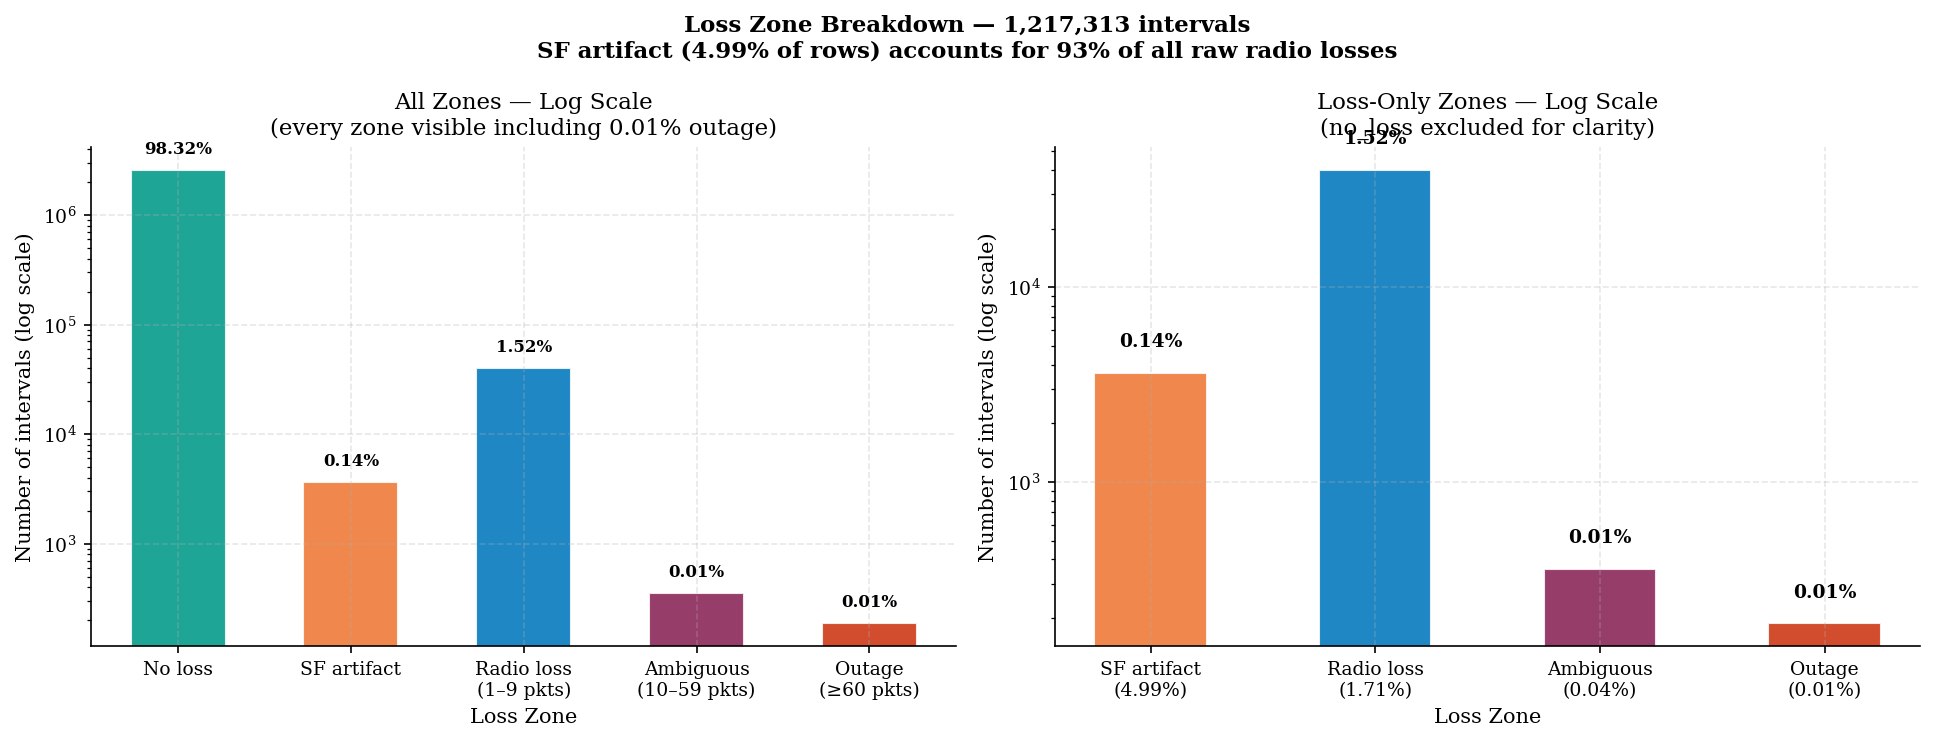

In [46]:
# Fig 01_c — Loss Zone Breakdown
zones = ['no_loss', 'sf_artifact', 'radio_loss', 'ambiguous', 'outage']
zlabels = ['No loss', 'SF artifact', 'Radio loss\n(1–9 pkts)', 'Ambiguous\n(10–59 pkts)', 'Outage\n(≥60 pkts)']
zcolors = [C['green'], C['orange'], C['blue'], C['brown'], C['red']]
counts = df['loss_zone'].value_counts().reindex(zones).fillna(0)
pcts = counts / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: all 5 zones — log scale
bars = axes[0].bar(zlabels, counts.values, color=zcolors, width=0.55, alpha=0.88, edgecolor='white')
axes[0].set_yscale('log')
for bar, cnt, pct in zip(bars, counts.values, pcts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, cnt * 1.3,
                 f'{pct:.2f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_ylabel('Number of intervals (log scale)')
axes[0].set_xlabel('Loss Zone')
axes[0].set_title('All Zones — Log Scale\n(every zone visible including 0.01% outage)')

# right: loss-only zones — also log scale
loss_zones = ['sf_artifact', 'radio_loss', 'ambiguous', 'outage']
loss_labels = ['SF artifact\n(4.99%)', 'Radio loss\n(1.71%)', 'Ambiguous\n(0.04%)', 'Outage\n(0.01%)']
loss_colors = [C['orange'], C['blue'], C['brown'], C['red']]
loss_counts = [counts[z] for z in loss_zones]
loss_pcts = [pcts[z] for z in loss_zones]
bars2 = axes[1].bar(loss_labels, loss_counts, color=loss_colors,
                    width=0.5, alpha=0.88, edgecolor='white')
axes[1].set_yscale('log')
for bar, cnt, pct in zip(bars2, loss_counts, loss_pcts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, cnt * 1.3,
                 f'{pct:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_ylabel('Number of intervals (log scale)')
axes[1].set_xlabel('Loss Zone')
axes[1].set_title('Loss-Only Zones — Log Scale\n(no_loss excluded for clarity)')

fig.suptitle('Loss Zone Breakdown — 1,217,313 intervals\n'
             'SF artifact (4.99% of rows) accounts for 93% of all raw radio losses',
             fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_c_loss_zones')

## 8 · PDR Decomposition  *(§7.1)*

Three PDR values are computed — each progressively excluding non-environmental losses.  
This decomposition is the primary methodological contribution of this thesis.

| PDR | Excludes | Answers |
|-----|---------|---------|
| `PDR_system` | Nothing — application-layer perspective | What fraction of all intended transmissions arrived? |
| `PDR_raw` | Nothing — radio perspective | What fraction of radio attempts arrived? |
| `PDR_radio` | Outages + SF artifacts | What is the true radio link reliability? |

**`PDR_radio` is used for all event-conditioned analysis in notebooks 03–04.**

In [47]:
def compute_pdr(data):
    rx, lost = len(data), int(data['mac_to_radio_loss'].sum())
    return rx / (rx + lost) * 100 if (rx + lost) > 0 else 0


pdr_raw = compute_pdr(df)
pdr_radio = compute_pdr(df[~df['is_outage'] & ~df['is_sf_artifact']])

print(f'PDR_raw   (all radio losses)              : {pdr_raw:.2f}%')
print(f'PDR_radio (excl. outages + SF artifacts)  : {pdr_radio:.2f}%')
print(f'Gap                                       : {pdr_radio - pdr_raw:.2f} pp')
print(f'\nThe {pdr_radio - pdr_raw:.2f} pp gap represents losses attributable to')
print(f'infrastructure downtime and SF rotation artifacts — not environmental events.')

PDR_raw   (all radio losses)              : 91.04%
PDR_radio (excl. outages + SF artifacts)  : 97.75%
Gap                                       : 6.71 pp

The 6.71 pp gap represents losses attributable to
infrastructure downtime and SF rotation artifacts — not environmental events.


  Saved: figures/01_d_pdr_decomposition_per_device.pdf + .png


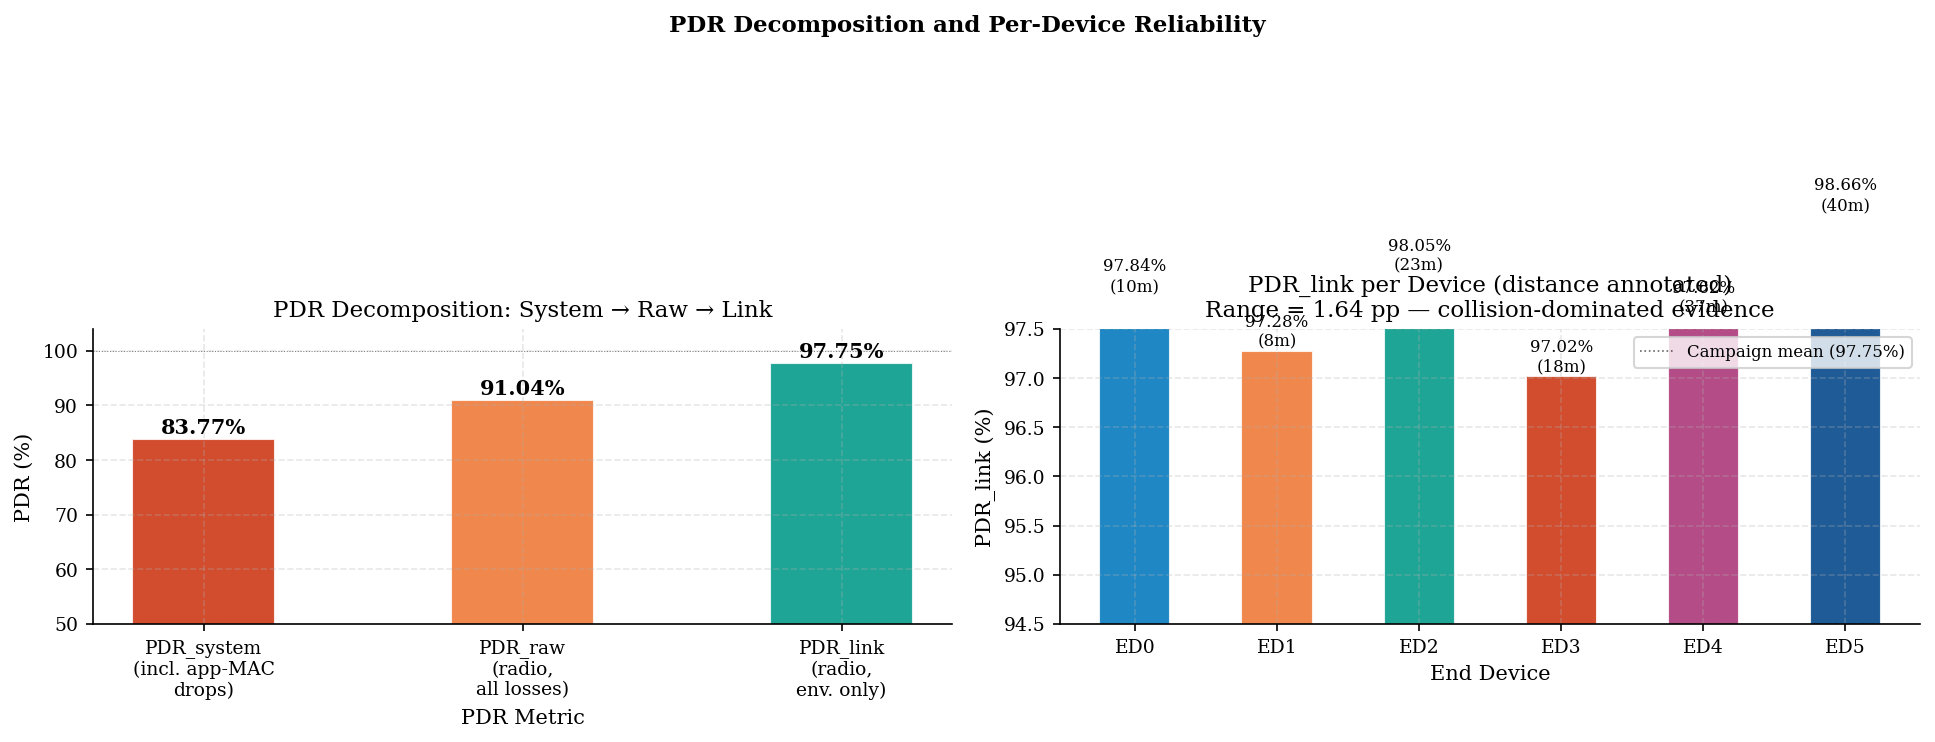

In [48]:
    # Fig 01_c — PDR Decomposition + Per-Device PDR_link
rx_all = len(df)
lost_system = int(df['total_loss'].sum())
lost_raw = int(df['mac_to_radio_loss'].sum())
df_link_tmp = df[~df['is_outage'] & ~df['is_sf_artifact']]
lost_link = int(df_link_tmp['mac_to_radio_loss'].sum())
pdr_system_v = rx_all / (rx_all + lost_system) * 100
pdr_raw_v = rx_all / (rx_all + lost_raw) * 100
pdr_link_v = len(df_link_tmp) / (len(df_link_tmp) + lost_link) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# left: vertical bars — PDR_system, PDR_raw, PDR_link
categories = ['PDR_system\n(incl. app-MAC\ndrops)', 'PDR_raw\n(radio,\nall losses)', 'PDR_link\n(radio,\nenv. only)']
values_v = [pdr_system_v, pdr_raw_v, pdr_link_v]
colors_v = [C['red'], C['orange'], C['green']]
bars = axes[0].bar(categories, values_v, color=colors_v, width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, values_v):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.3,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(50, 104)
axes[0].set_ylabel('PDR (%)')
axes[0].set_xlabel('PDR Metric')
axes[0].axhline(y=100, color='grey', lw=0.5, ls=':')
axes[0].set_title('PDR Decomposition: System → Raw → Link')

# right: PDR_link per device with distance annotated
DEVICES_P = sorted(df['device_id'].unique())
dev_pdrs, dev_dists = [], []
for dev in DEVICES_P:
    g = df_link_tmp[df_link_tmp['device_id'] == dev]
    rx = len(g);
    lost = int(g['mac_to_radio_loss'].sum())
    dev_pdrs.append(rx / (rx + lost) * 100)
    dev_dists.append(int(df[df['device_id'] == dev]['distance'].iloc[0]))

bars2 = axes[1].bar(DEVICES_P, dev_pdrs,
                    color=DEVICE_COLORS[:len(DEVICES_P)], width=0.5, alpha=0.88, edgecolor='white')
for bar, v, d in zip(bars2, dev_pdrs, dev_dists):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                 f'{v:.2f}%\n({d}m)', ha='center', va='bottom', fontsize=8)
axes[1].axhline(y=pdr_link_v, color='black', lw=0.8, ls=':', alpha=0.6,
                label=f'Campaign mean ({pdr_link_v:.2f}%)')
axes[1].set_ylabel('PDR_link (%)')
axes[1].set_xlabel('End Device')
axes[1].set_ylim(94.5, 97.5)
axes[1].set_title(
    f'PDR_link per Device (distance annotated)\nRange = {max(dev_pdrs) - min(dev_pdrs):.2f} pp — collision-dominated evidence')
axes[1].legend(fontsize=8)

fig.suptitle('PDR Decomposition and Per-Device Reliability', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_d_pdr_decomposition_per_device')

## 9 · Loss Decomposition Table  *(Table 7.1, §7.1)*

Full per-device breakdown of all loss components.  
`Total Lost = App-MAC + MAC-Radio` where `MAC-Radio = Artifact + Outage + Link Loss`.  
**`PDR_link` is the event-conditioned analysis metric — copy these values to Table 7.1.**

In [49]:
print(f"{'Dev':<6} {'Dist':^6} {'CW':^4} {'WW':^4} "
      f"{'Received':^10} {'Total Lost':^11} {'App-MAC':^9} {'MAC-Radio':^11} "
      f"{'Artifact':^10} {'Outage':^9} {'Link Loss':^11} "
      f"{'PDR_system':^11} {'PDR_link':^10} {'Resets':^7}")
print('-' * 145)

totals = {k: 0 for k in ['rx', 'app_mac', 'artifact', 'outage', 'link']}

for dev, g in df.groupby('device_id'):
    rx = len(g)
    app_mac = int(g['app_to_mac_drop'].sum())
    artifact = int(g[g['is_sf_artifact']]['mac_to_radio_loss'].sum())
    outage = int(g[g['is_outage']]['mac_to_radio_loss'].sum())
    g_link = g[~g['is_outage'] & ~g['is_sf_artifact']]
    link = int(g_link['mac_to_radio_loss'].sum())
    mac_radio = artifact + outage + link
    total_lost = app_mac + mac_radio

    for k, v in [('rx', rx), ('app_mac', app_mac), ('artifact', artifact), ('outage', outage), ('link', link)]:
        totals[k] += v

    pdr_system = rx / (rx + total_lost) * 100
    pdr_link = len(g_link) / (len(g_link) + link) * 100
    dist = int(g['distance'].iloc[0])
    cw = int(g['c_walls'].iloc[0])
    ww = int(g['w_walls'].iloc[0])
    rst = int(g['is_reset'].sum())

    print(f"{dev:<6} {dist:^6} {cw:^4} {ww:^4} "
          f"{rx:^10,} {total_lost:^11,} {app_mac:^9,} {mac_radio:^11,} "
          f"{artifact:^10,} {outage:^9,} {link:^11,} "
          f"{pdr_system:^11.2f} {pdr_link:^10.2f} {rst:^7}")

print('-' * 145)
t = totals
mac_r = t['artifact'] + t['outage'] + t['link']
total = t['app_mac'] + mac_r
print(f"{'Total':<6} {'':^6} {'':^4} {'':^4} "
      f"{t['rx']:^10,} {total:^11,} {t['app_mac']:^9,} {mac_r:^11,} "
      f"{t['artifact']:^10,} {t['outage']:^9,} {t['link']:^11,} "
      f"{t['rx'] / (t['rx'] + total) * 100:^11.2f} {t['rx'] / (t['rx'] + t['link']) * 100:^10.2f}")

Dev     Dist   CW   WW   Received  Total Lost   App-MAC   MAC-Radio   Artifact   Outage    Link Loss  PDR_system   PDR_link  Resets 
-------------------------------------------------------------------------------------------------------------------------------------------------
ED0      10    0    0    440,166     82,310     39,670     42,640       751      32,182      9,707       84.25      97.84       8   
ED1      8     1    0    434,548     90,240     44,862     45,378       760      32,469     12,149       82.80      97.28       3   
ED2      23    0    2    440,920     83,905     42,083     41,822       719      32,337      8,766       84.01      98.05       3   
ED3      18    1    2    433,579     90,165     43,688     46,477       870      32,321     13,286       82.78      97.02       6   
ED4      37    0    5    435,416     89,358     45,534     43,824       868      32,377     10,579       82.97      97.62       2   
ED5      40    2    2    450,301     74,636     35,533  

## 10 · Column Order & Save

Columns reordered logically — originals first, derived last.

| Group | Columns |
|-------|---------|
| Identifiers | `device_id`, `time` |
| Environmental | `co2`, `humidity`, `pm25`, `pressure`, `temperature` |
| Radio metrics | `rssi`, `snr`, `esp`, `SF`, `frequency`, `toa` |
| Spatial | `distance`, `c_walls`, `w_walls`, `exp_pl`, `n_power` |
| Raw counters | `f_count`, `p_count` |
| Derived | all new columns from this notebook |

In [50]:
original_cols = [
    'device_id', 'time',
    'co2', 'humidity', 'pm25', 'pressure', 'temperature',
    'rssi', 'snr', 'esp', 'SF', 'frequency', 'toa',
    'distance', 'c_walls', 'w_walls', 'exp_pl', 'n_power',
    'f_count', 'p_count',
]
derived_cols = [
    'mac_to_radio_loss',  # primary — radio losses
    'app_to_mac_drop',  # future work — app-to-MAC drops
    'total_loss',  # cross-validation — p_count equivalent
    'total_tx',  # TX attempts per interval
    'is_reset',  # device reboot flag
    'is_outage',  # infrastructure outage flag
    'is_sf_artifact',  # SF rotation artifact flag
    'loss_zone',  # zone classification
]

final_cols = [c for c in original_cols if c in df.columns] + derived_cols
df = df[final_cols]

df.to_csv(OUT_CSV, index=False)
print(f'Saved : {OUT_CSV}')
print(f'Rows  : {len(df):,}')
print(f'Cols  : {len(df.columns)}')

Saved : ..\data\1_reconstructed.csv
Rows  : 2,634,930
Cols  : 28
